# A. Topic Modelling dengan Latent Dirichlet Allocation (LDA)

In [ ]:
import pandas as pd
from google.colab import files

# Upload file CSV
uploaded = files.upload()

# Membaca file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Menampilkan 10 data pertama
df.head(10)

Saving ulasan_plnmobile_preprocessing.csv to ulasan_plnmobile_preprocessing.csv


,nama,rating,final_text,tanggal,sumber
0,kus wanto,5.0,aplikasi manfaat urus listrik,2025-09-26 00:05:57,ulasan_plnmobile_googleplaystore.csv
1,askhar muda,5.0,bantu proses adu,2025-09-26 00:08:49,ulasan_plnmobile_googleplaystore.csv
2,Heru Cahyono,5.0,mudah cepat tanggap,2025-09-26 00:09:27,ulasan_plnmobile_googleplaystore.csv
3,Venitri Kudji Ratu,5.0,hadir aplikasi ganggu listrik rumah,2025-09-26 00:14:52,ulasan_plnmobile_googleplaystore.csv
4,Felix __,5.0,lapor langsung pln pakai pln mobile mudah cepa...,2025-09-26 00:25:25,ulasan_plnmobile_googleplaystore.csv
5,Baso Itung,5.0,bantu langgan,2025-09-26 00:39:53,ulasan_plnmobile_googleplaystore.csv
6,Omteddy Teddy,5.0,mudah percaya,2025-09-26 00:44:09,ulasan_plnmobile_googleplaystore.csv
7,Misra Misra,5.0,semenjak aplikasi pln mobile mudah laku ganggu...,2025-09-26 00:44:36,ulasan_plnmobile_googleplaystore.csv
8,Rosna Kolo,5.0,pln baik aplikasi pln mobile,2025-09-26 00:44:57,ulasan_plnmobile_googleplaystore.csv
9,izi muhsin,5.0,tingkat layan ulp,2025-09-26 00:46:33,ulasan_plnmobile_googleplaystore.csv


# Mengecek Missing Values

In [ ]:
# Kolom yang akan dicek
columns_to_check = [
    'final_text'
]

# Menghitung jumlah missing values
missing_values = df[columns_to_check].isnull().sum()

# Menampilkan dalam bentuk tabel
missing_values_df = missing_values.reset_index()
missing_values_df.columns = ['Kolom', 'Jumlah Missing']

missing_values_df


,Kolom,Jumlah Missing
0,final_text,0


# Persiapan Data dan Penerapan LDA

In [ ]:
# Memisahkan teks menjadi token (list kata)
df['tokens'] = df['final_text'].apply(lambda x: x.split())
df[['final_text', 'tokens']].head()

# Mengambil seluruh token ulasan
texts = df['tokens'].tolist()

# Contoh hasil
texts[:3]

[['aplikasi', 'manfaat', 'urus', 'listrik'],
 ['bantu', 'proses', 'adu'],
 ['mudah', 'cepat', 'tanggap']]

In [ ]:
!pip install gensim

from gensim.corpora import Dictionary

# Membuat dictionary dari token
dictionary = Dictionary(texts)

# Melihat jumlah kata unik
print(f"Jumlah kata unik: {len(dictionary)}")

# Mengonversi setiap dokumen ke representasi Bag of Words
corpus = [dictionary.doc2bow(text) for text in texts]

# Contoh BoW
corpus[:3]

# Menyiapkan Daftar Penyimpanan Coherence Score
coherence_scores = []

# Mengatur Jumlah Topik yang Diekstrak (10 Topik)
num_topics_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Menentukan Seed untuk Hasil yang Konsisten
random_state = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.6 MB/s eta 0:00:00
Jumlah kata unik: 5002


In [ ]:
# Inisialisasi Model dan Penyimpanan Hasil
from gensim.models import LdaModel

lda_models = []

# Pelatihan Model LDA dengan Berbagai Jumlah Topik
for num_topics in num_topics_list:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        chunksize=100,
        passes=10,
        alpha='auto',
    )

    # Penyimpanan model LDA
    lda_models.append(lda_model)

In [ ]:
print("=== EKSPLORASI AWAL TOPIK LDA ===\n")

for i, num_topics in enumerate(num_topics_list):
    # Menampilkan informasi jumlah topik
    print(f"\nJumlah Topik: {num_topics}")
    print("-" * 40)

    # Mengambil kata kunci topik
    topics = lda_models[i].print_topics(num_words=10)

    # Menampilkan setiap topik
    for idx, topic in topics:
        print(f"Topik {idx + 1}: {topic}")


=== EKSPLORASI AWAL TOPIK LDA ===


Jumlah Topik: 2
----------------------------------------
Topik 1: 0.077*"mudah" + 0.077*"aplikasi" + 0.054*"listrik" + 0.052*"bantu" + 0.022*"lapor" + 0.021*"adu" + 0.021*"token" + 0.021*"bayar" + 0.020*"guna" + 0.020*"beli"
Topik 2: 0.149*"pln" + 0.080*"mobile" + 0.069*"cepat" + 0.055*"layan" + 0.038*"baik" + 0.032*"makin" + 0.022*"tugas" + 0.015*"respon" + 0.012*"langsung" + 0.010*"tangan"

Jumlah Topik: 3
----------------------------------------
Topik 1: 0.109*"mudah" + 0.109*"aplikasi" + 0.076*"listrik" + 0.073*"bantu" + 0.031*"lapor" + 0.030*"token" + 0.030*"adu" + 0.029*"bayar" + 0.028*"guna" + 0.028*"beli"
Topik 2: 0.185*"pln" + 0.099*"mobile" + 0.086*"cepat" + 0.068*"layan" + 0.047*"baik" + 0.037*"makin" + 0.027*"tugas" + 0.018*"respon" + 0.013*"tangan" + 0.013*"moga"
Topik 3: 0.042*"baru" + 0.033*"daya" + 0.027*"pasang" + 0.024*"tambah" + 0.019*"proses" + 0.017*"perlu" + 0.016*"lain" + 0.013*"lewat" + 0.012*"lama" + 0.012*"mau"

Jumlah Topik

In [ ]:
# Import modul CoherenceModel dari gensim
from gensim.models.coherencemodel import CoherenceModel

# List untuk menyimpan nilai coherence score
coherence_scores = []

print("=== HASIL COHERENCE SCORE TOPIC MODELLING LDA ===\n")

# Perulangan untuk setiap model LDA
for i, lda_model in enumerate(lda_models):

    # Membuat objek CoherenceModel
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    # Menghitung coherence score
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

    # Menampilkan coherence score untuk setiap jumlah topik
    print(f"Jumlah Topik: {num_topics_list[i]} | Coherence Score (c_v): {coherence:.4f}")


=== HASIL COHERENCE SCORE TOPIC MODELLING LDA ===

Jumlah Topik: 2 | Coherence Score (c_v): 0.5543
Jumlah Topik: 3 | Coherence Score (c_v): 0.5190
Jumlah Topik: 4 | Coherence Score (c_v): 0.4495
Jumlah Topik: 5 | Coherence Score (c_v): 0.4210
Jumlah Topik: 6 | Coherence Score (c_v): 0.4275
Jumlah Topik: 7 | Coherence Score (c_v): 0.3707
Jumlah Topik: 8 | Coherence Score (c_v): 0.3383
Jumlah Topik: 9 | Coherence Score (c_v): 0.3904
Jumlah Topik: 10 | Coherence Score (c_v): 0.3971


In [ ]:
# Menentukan Model LDA Terbaik
best_index = coherence_scores.index(max(coherence_scores))
best_num_topics = num_topics_list[best_index]
best_coherence = coherence_scores[best_index]
best_lda_model = lda_models[best_index]

# Menampilkan Hasil Akhir Pemodelan LDA
print("\n=== HASIL AKHIR PEMODELAN LDA ===")
print(f"Jumlah topik terbaik   : {best_num_topics}")
print(f"Coherence score tertinggi (c_v): {best_coherence:.4f}")


=== HASIL AKHIR PEMODELAN LDA ===
Jumlah topik terbaik   : 2
Coherence score tertinggi (c_v): 0.5543


# Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Ambil distribusi kata per topik dari Gensim LDA
lda_topic_word = lda_model.get_topics()

# Hitung cosine similarity antar topik
lda_similarity = cosine_similarity(lda_topic_word)

# Buat DataFrame
lda_similarity_df = pd.DataFrame(
    lda_similarity,
    index=[f"Topik {i+1}" for i in range(lda_topic_word.shape[0])],
    columns=[f"Topik {i+1}" for i in range(lda_topic_word.shape[0])]
)

lda_similarity_df


,Topik 1,Topik 2,Topik 3,Topik 4,Topik 5,Topik 6,Topik 7,Topik 8,Topik 9,Topik 10
Topik 1,1.000003,0.000236,0.000235,0.000729,0.000119,0.000326,0.000116,0.000299,0.000191,0.000098
Topik 2,0.000236,1.000005,0.000368,0.001320,0.000140,0.000485,0.000162,0.000416,0.000306,0.000121
Topik 3,0.000235,0.000368,1.000009,0.001049,0.000188,0.000509,0.000178,0.000459,0.000284,0.000154
Topik 4,0.000729,0.001320,0.001049,0.999991,0.000763,0.001752,0.000618,0.001612,0.000822,0.000601
Topik 5,0.000119,0.000140,0.000188,0.000763,1.000000,0.000206,0.000075,0.000189,0.000161,0.000048
Topik 6,0.000326,0.000485,0.000509,0.001752,0.000206,1.000011,0.000228,0.000608,0.000416,0.000177
Topik 7,0.000116,0.000162,0.000178,0.000618,0.000075,0.000228,1.000000,0.000210,0.000148,0.000064
Topik 8,0.000299,0.000416,0.000459,0.001612,0.000189,0.000608,0.000210,1.000006,0.000381,0.000163
Topik 9,0.000191,0.000306,0.000284,0.000822,0.000161,0.000416,0.000148,0.000381,1.000005,0.000131
Topik 10,0.000098,0.000121,0.000154,0.000601,0.000048,0.000177,0.000064,0.000163,0.000131,1.000000


In [ ]:
# ============================================================================
# MENGECEK ASSIGNMENT DOKUMEN KE TOPIK - LDA
# ============================================================================

print("="*60)
print("DOKUMEN ASSIGNMENT - LDA")
print("="*60 + "\n")

# Pilih model LDA terbaik (misalnya dengan 10 topik)
best_lda_model = lda_models[best_index]  # dari hasil sebelumnya
best_num_topics = num_topics_list[best_index]

print(f"Menggunakan model LDA dengan {best_num_topics} topik\n")

# Dapatkan distribusi topik untuk setiap dokumen
doc_topics = []
for doc_bow in corpus:
    topic_distribution = best_lda_model.get_document_topics(doc_bow)
    doc_topics.append(topic_distribution)

# Tampilkan 10 dokumen pertama
print("="*60)
print("10 DOKUMEN PERTAMA DAN TOPIK ASSIGNMENT")
print("="*60 + "\n")

for i in range(10):
    print(f"Dokumen {i+1}:")
    print(f"  Teks: {df['final_text'].iloc[i][:100]}...")
    print(f"  Distribusi Topik:")

    # Urutkan berdasarkan probabilitas
    sorted_topics = sorted(doc_topics[i], key=lambda x: x[1], reverse=True)

    for topic_id, prob in sorted_topics[:3]:  # Top 3 topik
        print(f"    Topik {topic_id + 1}: {prob:.4f} ({prob*100:.2f}%)")

    # Topik dominan
    dominant_topic = max(doc_topics[i], key=lambda x: x[1])
    print(f"  → Topik Dominan: Topik {dominant_topic[0] + 1} ({dominant_topic[1]*100:.2f}%)")
    print()

DOKUMEN ASSIGNMENT - LDA

Menggunakan model LDA dengan 2 topik

10 DOKUMEN PERTAMA DAN TOPIK ASSIGNMENT

Dokumen 1:
  Teks: aplikasi manfaat urus listrik...
  Distribusi Topik:
    Topik 1: 0.8012 (80.12%)
    Topik 2: 0.1988 (19.88%)
  → Topik Dominan: Topik 1 (80.12%)

Dokumen 2:
  Teks: bantu proses adu...
  Distribusi Topik:
    Topik 1: 0.7707 (77.07%)
    Topik 2: 0.2293 (22.93%)
  → Topik Dominan: Topik 1 (77.07%)

Dokumen 3:
  Teks: mudah cepat tanggap...
  Distribusi Topik:
    Topik 2: 0.5356 (53.56%)
    Topik 1: 0.4644 (46.44%)
  → Topik Dominan: Topik 2 (53.56%)

Dokumen 4:
  Teks: hadir aplikasi ganggu listrik rumah...
  Distribusi Topik:
    Topik 1: 0.7166 (71.66%)
    Topik 2: 0.2834 (28.34%)
  → Topik Dominan: Topik 1 (71.66%)

Dokumen 5:
  Teks: lapor langsung pln pakai pln mobile mudah cepat tangan puas...
  Distribusi Topik:
    Topik 2: 0.6282 (62.82%)
    Topik 1: 0.3718 (37.18%)
  → Topik Dominan: Topik 2 (62.82%)

Dokumen 6:
  Teks: bantu langgan...
  Distribus

MEMBUAT DATAFRAME ASSIGNMENT - LDA

Contoh 10 dokumen dengan topik assignment:
                                          final_text  LDA_Topic  \
0                      aplikasi manfaat urus listrik          1   
1                                   bantu proses adu          1   
2                                mudah cepat tanggap          2   
3                hadir aplikasi ganggu listrik rumah          1   
4  lapor langsung pln pakai pln mobile mudah cepa...          2   
5                                      bantu langgan          1   
6                                      mudah percaya          1   
7  semenjak aplikasi pln mobile mudah laku ganggu...          1   
8                       pln baik aplikasi pln mobile          2   
9                                  tingkat layan ulp          2   

   LDA_Topic_Prob                            LDA_Keywords  
0        0.801217  mudah, aplikasi, listrik, bantu, lapor  
1        0.770726  mudah, aplikasi, listrik, bantu, lapor  
2  

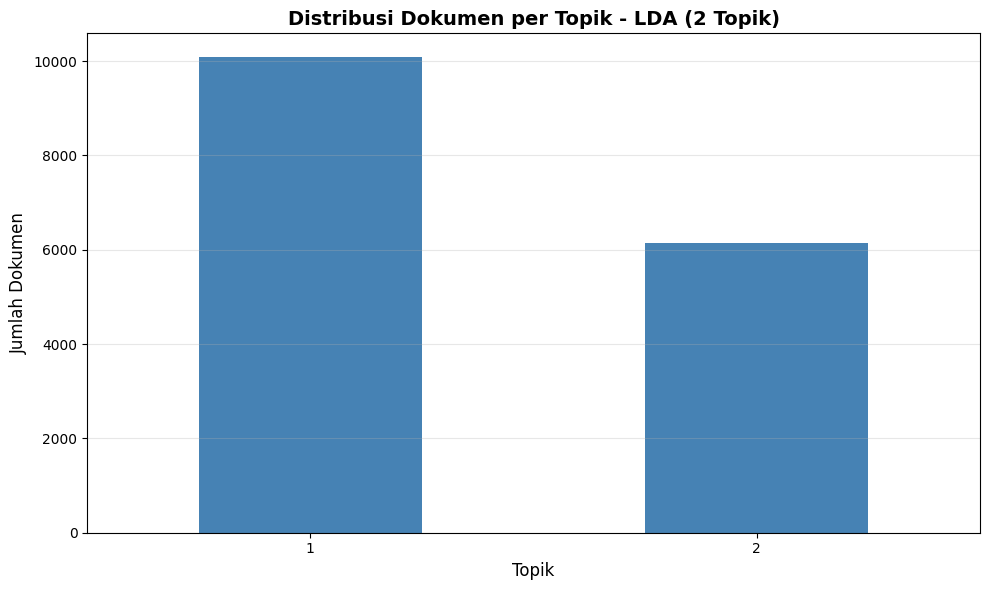

In [ ]:
# ============================================================================
# MEMBUAT DATAFRAME LENGKAP ASSIGNMENT DOKUMEN - LDA
# ============================================================================

print("="*60)
print("MEMBUAT DATAFRAME ASSIGNMENT - LDA")
print("="*60 + "\n")

# Fungsi untuk mendapatkan topik dominan
def get_dominant_topic_lda(lda_model, corpus):
    """
    Mendapatkan topik dominan untuk setiap dokumen

    Returns:
    --------
    DataFrame dengan kolom: Document_No, Dominant_Topic, Topic_Prob, Keywords
    """
    topics_data = []

    for idx, doc_bow in enumerate(corpus):
        # Dapatkan distribusi topik
        topic_distribution = lda_model.get_document_topics(doc_bow)

        # Topik dominan
        if topic_distribution:
            dominant_topic = max(topic_distribution, key=lambda x: x[1])
            topic_id = dominant_topic[0]
            topic_prob = dominant_topic[1]

            # Kata kunci topik
            topic_keywords = lda_model.show_topic(topic_id, topn=5)
            keywords = ", ".join([word for word, _ in topic_keywords])

            topics_data.append({
                'Document_No': idx,
                'Dominant_Topic': topic_id + 1,  # +1 agar mulai dari 1
                'Topic_Probability': topic_prob,
                'Topic_Keywords': keywords
            })
        else:
            topics_data.append({
                'Document_No': idx,
                'Dominant_Topic': None,
                'Topic_Probability': 0.0,
                'Topic_Keywords': ''
            })

    return pd.DataFrame(topics_data)

# Buat DataFrame
lda_assignments = get_dominant_topic_lda(best_lda_model, corpus)

# Gabungkan dengan data asli
df_with_lda_topics = df.copy()
df_with_lda_topics['LDA_Topic'] = lda_assignments['Dominant_Topic']
df_with_lda_topics['LDA_Topic_Prob'] = lda_assignments['Topic_Probability']
df_with_lda_topics['LDA_Keywords'] = lda_assignments['Topic_Keywords']

# Tampilkan hasil
print("Contoh 10 dokumen dengan topik assignment:")
print(df_with_lda_topics[['final_text', 'LDA_Topic', 'LDA_Topic_Prob', 'LDA_Keywords']].head(10))

# Statistik distribusi dokumen per topik
print("\n" + "="*60)
print("DISTRIBUSI DOKUMEN PER TOPIK - LDA")
print("="*60 + "\n")

topic_counts = df_with_lda_topics['LDA_Topic'].value_counts().sort_index()
print(topic_counts)

# Visualisasi
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='steelblue')
plt.xlabel('Topik', fontsize=12)
plt.ylabel('Jumlah Dokumen', fontsize=12)
plt.title(f'Distribusi Dokumen per Topik - LDA ({best_num_topics} Topik)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# DOKUMEN REPRESENTATIF PER TOPIK - LDA
# ============================================================================

print("="*60)
print("DOKUMEN REPRESENTATIF PER TOPIK - LDA")
print("="*60 + "\n")

def get_representative_docs_lda(df_with_topics, n_docs=5):
    """
    Mendapatkan dokumen paling representatif untuk setiap topik
    """
    for topic_id in sorted(df_with_topics['LDA_Topic'].unique()):
        if pd.isna(topic_id):
            continue

        print(f"\n{'='*60}")
        print(f"TOPIK {int(topic_id)}")
        print(f"{'='*60}")

        # Filter dokumen untuk topik ini
        topic_docs = df_with_topics[df_with_topics['LDA_Topic'] == topic_id]

        # Urutkan berdasarkan probabilitas tertinggi
        top_docs = topic_docs.nlargest(n_docs, 'LDA_Topic_Prob')

        print(f"\nKata Kunci: {top_docs.iloc[0]['LDA_Keywords']}")
        print(f"Jumlah Dokumen: {len(topic_docs)}")
        print(f"\nTop {n_docs} Dokumen Representatif:\n")

        for idx, row in top_docs.iterrows():
            print(f"{idx+1}. (Prob: {row['LDA_Topic_Prob']:.4f})")
            print(f"   {row['final_text'][:150]}...")
            print()

# Panggil fungsi
get_representative_docs_lda(df_with_lda_topics, n_docs=5)

DOKUMEN REPRESENTATIF PER TOPIK - LDA


TOPIK 1

Kata Kunci: mudah, aplikasi, listrik, bantu, lapor
Jumlah Dokumen: 10084

Top 5 Dokumen Representatif:

12155. (Prob: 0.9438)
   aplikasi mudah beli token bayar tagih pascabayar pantau guna listrik sedia informasi penting notifikasi madam jadwal pelihara promo tarik aplikasi ama...

11888. (Prob: 0.9433)
   aplikasi benar benar manfaat mudah transaksi beli token bayar listrik bulan tampil menu menu lengkap aju pasang baru tambah daya pengajauan ganggu lis...

14097. (Prob: 0.9407)
   fitur lengkap satu aplikasi cek token bayar hingga informasi madam akses satu aplikasi fitur pantau guna listrik informatif kontrol biaya listrik bula...

12502. (Prob: 0.9336)
   aplikasi bantu beli token listrik cek tagih tambah daya lapor ganggu tambah daya daftar pasang baru fitur mudah langgan...

11171. (Prob: 0.9332)
   halo min mohon izin uras data bagaimana pilih masuk email masuk email versi belum lalu masuk minta baharu log out hilang pilih buat e

# B. Topic Modelling dengan BERTopic

In [ ]:
# Install library yang diperlukan
!pip install bertopic
!pip install sentence-transformers

# Import library
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# Persiapan Data untuk BERTopic

In [ ]:
print("Mempersiapkan data untuk BERTopic...")

# Mengambil teks yang sudah dibersihkan
documents = df['final_text'].tolist()

print(f"   Total dokumen: {len(documents)}")
print(f"   Contoh dokumen pertama: {documents[0][:100]}...\n")

Mempersiapkan data untuk BERTopic...
   Total dokumen: 16220
   Contoh dokumen pertama: aplikasi manfaat urus listrik...



# Inisialisasi Model Embedding dan Konfigurasi BERTopic

In [ ]:
# Inisialisasi Model Embedding
print("Menginisialisasi model embedding...")

# Menggunakan model multilingual untuk mendukung bahasa Indonesia
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("   Model embedding: paraphrase-multilingual-MiniLM-L12-v2")
print("   (Model ini mendukung bahasa Indonesia)\n")

# Konfigurasi BERTopic
print("Mengkonfigurasi BERTopic...")

# Konfigurasi CountVectorizer untuk preprocessing
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),  # unigram dan bigram
    min_df=2  # kata harus muncul minimal di 2 dokumen
)

Menginisialisasi model embedding...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Model embedding: paraphrase-multilingual-MiniLM-L12-v2
   (Model ini mendukung bahasa Indonesia)

Mengkonfigurasi BERTopic...


# Training BERTopic dengan Berbagai Jumlah Topik

In [ ]:
import random
from umap import UMAP
from hdbscan import HDBSCAN

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("="*60)
print("BERTOPIC DENGAN KONFIGURASI OPTIMAL")
print("="*60 + "\n")

bertopic_num_topics_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
bertopic_models = []
bertopic_topics_info = []

for num_topics in bertopic_num_topics_list:
    print(f"   Training BERTopic dengan {num_topics} topik...")

    # UMAP untuk dimensionality reduction yang lebih baik
    umap_model = UMAP(
        n_neighbors=15,
        n_components=10,
        min_dist=0.2,
        metric='cosine',
        random_state=RANDOM_SEED,
        transform_seed=RANDOM_SEED
    )

    # HDBSCAN untuk clustering yang lebih ketat
    hdbscan_model = HDBSCAN(
        min_cluster_size=30,
        min_samples=10,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    # Inisialisasi BERTopic dengan semua komponen custom
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        nr_topics=num_topics,
        min_topic_size=20,
        verbose=False,
        calculate_probabilities=True,
        low_memory=False
    )

    # Fit model
    topics, probabilities = topic_model.fit_transform(documents)

    # Simpan model
    bertopic_models.append(topic_model)

    # Dapatkan informasi topik
    topic_info = topic_model.get_topic_info()
    bertopic_topics_info.append(topic_info)

    actual_topics = len(topic_info) - 1  # -1 untuk outlier
    print(f"   ✓ Selesai. Topik terdeteksi: {actual_topics}")

print("\n   Semua model BERTopic berhasil dilatih!\n")

BERTOPIC DENGAN KONFIGURASI OPTIMAL

   Training BERTopic dengan 2 topik...
   ✓ Selesai. Topik terdeteksi: 1
   Training BERTopic dengan 3 topik...
   ✓ Selesai. Topik terdeteksi: 2
   Training BERTopic dengan 4 topik...
   ✓ Selesai. Topik terdeteksi: 3
   Training BERTopic dengan 5 topik...
   ✓ Selesai. Topik terdeteksi: 4
   Training BERTopic dengan 6 topik...
   ✓ Selesai. Topik terdeteksi: 5
   Training BERTopic dengan 7 topik...
   ✓ Selesai. Topik terdeteksi: 6
   Training BERTopic dengan 8 topik...
   ✓ Selesai. Topik terdeteksi: 7
   Training BERTopic dengan 9 topik...
   ✓ Selesai. Topik terdeteksi: 8
   Training BERTopic dengan 10 topik...
   ✓ Selesai. Topik terdeteksi: 9

   Semua model BERTopic berhasil dilatih!



BERTopic bekerja dalam 3 tahap :
1. Clustering : Menemukan cluster natural (bisa 20, 30, 50+ topik awal)
2. Reduction : Merge topik yang mirip hingga mendekati nr_topics
3. Outlier : Dokumen yang tidak cocok masuk ke topik -1

Ketika set nr_topics=10:

- BERTopic mencoba reduce topik hingga mendekati 10
- Tapi jika data hanya bisa di-cluster menjadi 9 topik yang koheren, maka hasilnya 9
- Ini karena BERTopic memprioritaskan kualitas topik daripada kuantitas

# Eksplorasi Topik BERTopic

In [ ]:
print("="*60)
print("EKSPLORASI TOPIK BERTOPIC")
print("="*60 + "\n")

for i, num_topics in enumerate(bertopic_num_topics_list):
    print(f"\nJumlah Topik yang Diminta: {num_topics}")
    print("-" * 60)

    topic_model = bertopic_models[i]
    topic_info = bertopic_topics_info[i]

    # Menampilkan topik (kecuali topik -1 yang merupakan outlier)
    actual_topics = topic_info[topic_info['Topic'] != -1]

    print(f"Topik yang Terbentuk: {len(actual_topics)}")
    print()

    for idx, row in actual_topics.iterrows():
        topic_id = row['Topic']
        topic_words = topic_model.get_topic(topic_id)

        # Format kata-kata topik
        words_str = ", ".join([f"{word} ({score:.3f})" for word, score in topic_words[:10]])

        print(f"Topik {topic_id + 1}:")
        print(f"  Jumlah Dokumen: {row['Count']}")
        print(f"  Kata Kunci: {words_str}")
        print()

EKSPLORASI TOPIK BERTOPIC


Jumlah Topik yang Diminta: 2
------------------------------------------------------------
Topik yang Terbentuk: 1

Topik 1:
  Jumlah Dokumen: 11508
  Kata Kunci: pln (0.118), aplikasi (0.092), mudah (0.090), listrik (0.087), bantu (0.081), mobile (0.081), pln mobile (0.080), cepat (0.069), layan (0.066), baik (0.044)


Jumlah Topik yang Diminta: 3
------------------------------------------------------------
Topik yang Terbentuk: 2

Topik 1:
  Jumlah Dokumen: 7800
  Kata Kunci: pln (0.097), aplikasi (0.096), listrik (0.094), mobile (0.086), pln mobile (0.085), mudah (0.082), bantu (0.069), token (0.039), aplikasi bantu (0.039), bayar (0.037)

Topik 2:
  Jumlah Dokumen: 3708
  Kata Kunci: layan (0.177), cepat (0.166), pln (0.108), baik (0.106), bantu (0.075), ramah (0.067), layan cepat (0.066), tugas (0.065), bagus (0.060), mudah (0.057)


Jumlah Topik yang Diminta: 4
------------------------------------------------------------
Topik yang Terbentuk: 3

Topik 1

# Mapping Aspek
1. Usability & Core Features
2. Service Quality
3. System Reliability & Authentication

# Menghitung Coherence Score BERTopic

In [ ]:
print("="*60)
print("MENGHITUNG COHERENCE SCORE BERTOPIC")
print("="*60 + "\n")

bertopic_coherence_scores = []

from gensim.models.coherencemodel import CoherenceModel

print("Menghitung coherence score c_v untuk setiap model BERTopic...\n")

for i, topic_model in enumerate(bertopic_models):
    # Ekstrak topik dari BERTopic
    bertopic_topics = []
    topic_info = bertopic_topics_info[i]

    # Ambil topik yang valid (bukan outlier -1)
    valid_topics = topic_info[topic_info['Topic'] != -1]['Topic'].tolist()

    for topic_id in valid_topics:
        # Ambil kata-kata dari topik
        topic_words = topic_model.get_topic(topic_id)
        # Ambil hanya kata-katanya (tanpa score)
        words = [word for word, _ in topic_words]
        bertopic_topics.append(words)

    # Hitung coherence score menggunakan gensim
    coherence_model = CoherenceModel(
        topics=bertopic_topics,
        texts=texts,  # menggunakan tokens dari LDA
        dictionary=dictionary,  # menggunakan dictionary dari LDA
        coherence='c_v'
    )

    coherence_score = coherence_model.get_coherence()
    bertopic_coherence_scores.append(coherence_score)

    print(f"Jumlah Topik: {bertopic_num_topics_list[i]} | Coherence Score (c_v): {coherence_score:.4f}")

MENGHITUNG COHERENCE SCORE BERTOPIC

Menghitung coherence score c_v untuk setiap model BERTopic...

Jumlah Topik: 2 | Coherence Score (c_v): 0.3754
Jumlah Topik: 3 | Coherence Score (c_v): 0.4900
Jumlah Topik: 4 | Coherence Score (c_v): 0.6707
Jumlah Topik: 5 | Coherence Score (c_v): 0.5998
Jumlah Topik: 6 | Coherence Score (c_v): 0.6093
Jumlah Topik: 7 | Coherence Score (c_v): 0.6025
Jumlah Topik: 8 | Coherence Score (c_v): 0.6124
Jumlah Topik: 9 | Coherence Score (c_v): 0.6088
Jumlah Topik: 10 | Coherence Score (c_v): 0.6241


# Menentukan Model BERTopic Terbaik

In [ ]:
print("\n" + "="*60)
print("HASIL AKHIR PEMODELAN BERTOPIC")
print("="*60)

best_bertopic_index = bertopic_coherence_scores.index(max(bertopic_coherence_scores))
best_bertopic_num_topics = bertopic_num_topics_list[best_bertopic_index]
best_bertopic_coherence = bertopic_coherence_scores[best_bertopic_index]
best_bertopic_model = bertopic_models[best_bertopic_index]

print(f"Jumlah topik terbaik        : {best_bertopic_num_topics}")
print(f"Coherence score tertinggi (c_v): {best_bertopic_coherence:.4f}")


HASIL AKHIR PEMODELAN BERTOPIC
Jumlah topik terbaik        : 4
Coherence score tertinggi (c_v): 0.6707


# Cosine Similarity BERTopic

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Ambil embedding topik
topic_embeddings = best_bertopic_model.topic_embeddings_

# Hitung cosine similarity
similarity_matrix = cosine_similarity(topic_embeddings)

# Buat DataFrame
topic_labels = [f"Topik {i}" for i in range(len(topic_embeddings))]
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=topic_labels,
    columns=topic_labels
)

similarity_df

,Topik 0,Topik 1,Topik 2,Topik 3
Topik 0,1.000000,0.938936,0.718916,0.533024
Topik 1,0.938936,1.000000,0.524923,0.528397
Topik 2,0.718916,0.524923,1.000000,0.326585
Topik 3,0.533024,0.528397,0.326585,1.000000


# Hierarchy

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(documents)

topic_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics
)


100%|██████████| 8/8 [00:00<00:00, 258.84it/s]


# Similarity Matrix

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_info = topic_model.get_topic_info()
topic_info

n_topics = topic_info[topic_info.Topic != -1].shape[0]
print("Jumlah topik aktual:", n_topics)

topic_model.visualize_heatmap()



Jumlah topik aktual: 9


In [ ]:
from sklearn.metrics.pairwise import cosine_distances

# Ambil topic info TANPA outlier
topics = topic_model.get_topic_info()
topics = topics[topics.Topic != -1]
topic_ids = topics.Topic.values

# Ambil embedding sesuai topic_ids
all_topic_embeddings = topic_model.topic_embeddings_
all_topic_ids = topic_model.get_topic_info().Topic.values

# Mapping topic_id -> embedding
embedding_dict = {
    topic_id: emb
    for topic_id, emb in zip(all_topic_ids, all_topic_embeddings)
    if topic_id != -1
}

# Susun embedding sesuai urutan topic_ids
topic_embeddings = np.array([embedding_dict[t] for t in topic_ids])

# Hitung cosine distance
distance_matrix = cosine_distances(topic_embeddings)

# DataFrame jarak
distance_df = pd.DataFrame(
    distance_matrix,
    index=topic_ids,
    columns=topic_ids
)

closest_topics = []

for topic in topic_ids:
    distances = distance_df.loc[topic]
    distances = distances[distances.index != topic]

    closest_topic = distances.idxmin()
    closest_distance = distances.min()

    closest_topics.append({
        "Topic": topic,
        "Closest_Topic": closest_topic,
        "Distance": closest_distance
    })

closest_topics_df = pd.DataFrame(closest_topics).sort_values("Distance")

def get_keywords(topic_id, n_words=5):
    return ", ".join([w for w, _ in topic_model.get_topic(topic_id)[:n_words]])

closest_topics_df["Topic_Keywords"] = closest_topics_df["Topic"].apply(get_keywords)
closest_topics_df["Closest_Topic_Keywords"] = closest_topics_df["Closest_Topic"].apply(get_keywords)

closest_topics_df



,Topic,Closest_Topic,Distance,Topic_Keywords,Closest_Topic_Keywords
0,0,3,0.267036,"listrik, mobile, pln mobile, pln, mudah","token, beli, beli token, transaksi, bayar"
3,3,0,0.267036,"token, beli, beli token, transaksi, bayar","listrik, mobile, pln mobile, pln, mudah"
2,2,3,0.276506,"aplikasi, aplikasi bantu, bantu, bantu aplikas...","token, beli, beli token, transaksi, bayar"
5,5,0,0.308444,"kwh, meter, catat, catat meter, kwh meter","listrik, mobile, pln mobile, pln, mudah"
1,1,2,0.320450,"layan, cepat, baik, pln, ramah","aplikasi, aplikasi bantu, bantu, bantu aplikas..."
7,7,1,0.390597,"lampu, malam, mati, jam, mati lampu","layan, cepat, baik, pln, ramah"
8,8,2,0.418089,"batu, aplikasi batu, batu aplikasi, batu mudah...","aplikasi, aplikasi bantu, bantu, bantu aplikas..."
6,6,1,0.419807,"pln pln, pln, pln is, is, is pln","layan, cepat, baik, pln, ramah"
4,4,3,0.425372,"email, verifikasi, masuk, kode, login","token, beli, beli token, transaksi, bayar"


# Merge

In [ ]:
# # Mengambil info topik
# topic_info = topic_model.get_topic_info()
# topic_info = topic_info[topic_info.Topic != -1]  # buang outlier


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity

# # hitung similarity matrix
# topic_embeddings = topic_model.topic_embeddings_[topic_info.Topic.values]
# similarity_matrix = cosine_similarity(topic_embeddings)

# # dataframe similarity
# labels = topic_info['Name'].values

# sim_df = pd.DataFrame(
#     similarity_matrix,
#     index=labels,
#     columns=labels
# )
# pairs = (
#     sim_df
#     .where(~np.eye(sim_df.shape[0], dtype=bool))
#     .stack()
#     .reset_index()
# )

# pairs.columns = ['Topic 3', 'Topic 4', 'Similarity']

# top_similar_topics = pairs.sort_values(
#     'Similarity', ascending=False
# ).head(20)

In [ ]:
# ============================================================================
# MENGECEK ASSIGNMENT DOKUMEN KE TOPIK - BERTOPIC
# ============================================================================

print("="*60)
print("DOKUMEN ASSIGNMENT - BERTOPIC")
print("="*60 + "\n")

# Pilih model BERTopic terbaik
best_bertopic_model = bertopic_models[best_bertopic_index]
best_bertopic_num_topics = bertopic_num_topics_list[best_bertopic_index]

print(f"Menggunakan model BERTopic dengan {best_bertopic_num_topics} topik\n")

# Dapatkan topik untuk setiap dokumen
topics_bertopic, probabilities_bertopic = best_bertopic_model.transform(documents)

# Tampilkan 10 dokumen pertama
print("="*60)
print("10 DOKUMEN PERTAMA DAN TOPIK ASSIGNMENT")
print("="*60 + "\n")

for i in range(10):
    topic_id = topics_bertopic[i]

    print(f"Dokumen {i+1}:")
    print(f"  Teks: {documents[i][:100]}...")

    if topic_id == -1:
        print(f"  → Topik: OUTLIER (tidak masuk topik manapun)")
    else:
        # Ambil kata kunci topik
        topic_words = best_bertopic_model.get_topic(topic_id)
        keywords = ", ".join([f"{word}" for word, _ in topic_words[:5]])

        # Probabilitas (jika tersedia)
        if probabilities_bertopic is not None and len(probabilities_bertopic) > i:
            prob = probabilities_bertopic[i][topic_id] if topic_id < len(probabilities_bertopic[i]) else 0.0
            print(f"  → Topik: {topic_id + 1} (Prob: {prob:.4f})")
        else:
            print(f"  → Topik: {topic_id + 1}")

        print(f"  Kata Kunci: {keywords}")
    print()

DOKUMEN ASSIGNMENT - BERTOPIC

Menggunakan model BERTopic dengan 4 topik

10 DOKUMEN PERTAMA DAN TOPIK ASSIGNMENT

Dokumen 1:
  Teks: aplikasi manfaat urus listrik...
  → Topik: 1 (Prob: 1.0000)
  Kata Kunci: pln, aplikasi, listrik, mobile, pln mobile

Dokumen 2:
  Teks: bantu proses adu...
  → Topik: 2 (Prob: 0.2682)
  Kata Kunci: layan, cepat, baik, pln, bantu

Dokumen 3:
  Teks: mudah cepat tanggap...
  → Topik: 2 (Prob: 0.6481)
  Kata Kunci: layan, cepat, baik, pln, bantu

Dokumen 4:
  Teks: hadir aplikasi ganggu listrik rumah...
  → Topik: 1 (Prob: 1.0000)
  Kata Kunci: pln, aplikasi, listrik, mobile, pln mobile

Dokumen 5:
  Teks: lapor langsung pln pakai pln mobile mudah cepat tangan puas...
  → Topik: 1 (Prob: 0.7545)
  Kata Kunci: pln, aplikasi, listrik, mobile, pln mobile

Dokumen 6:
  Teks: bantu langgan...
  → Topik: 2 (Prob: 0.2608)
  Kata Kunci: layan, cepat, baik, pln, bantu

Dokumen 7:
  Teks: mudah percaya...
  → Topik: OUTLIER (tidak masuk topik manapun)

Dokumen 8:
 

MEMBUAT DATAFRAME ASSIGNMENT - BERTOPIC

Contoh 10 dokumen dengan topik assignment:
                                          final_text BERTopic_Topic  \
0                      aplikasi manfaat urus listrik              1   
1                                   bantu proses adu              2   
2                                mudah cepat tanggap              2   
3                hadir aplikasi ganggu listrik rumah              1   
4  lapor langsung pln pakai pln mobile mudah cepa...              1   
5                                      bantu langgan              2   
6                                      mudah percaya        Outlier   
7  semenjak aplikasi pln mobile mudah laku ganggu...              1   
8                       pln baik aplikasi pln mobile              1   
9                                  tingkat layan ulp              2   

   BERTopic_Topic_Prob                           BERTopic_Keywords  
0             1.000000  pln, aplikasi, listrik, mobile, pln mobil

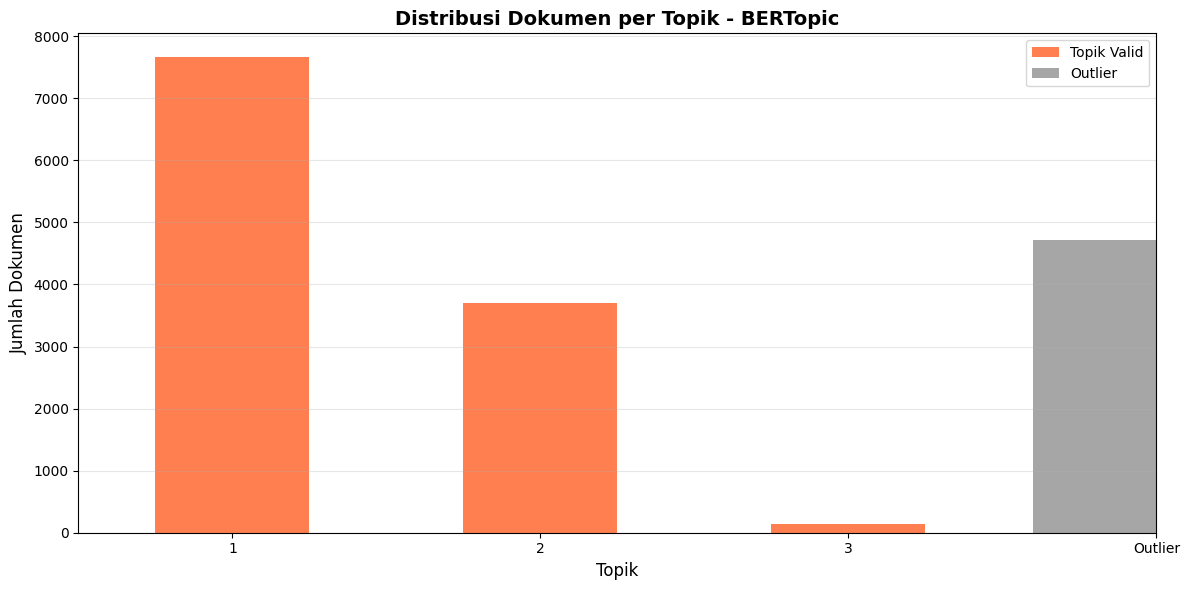


STATISTIK DISTRIBUSI

Jumlah topik yang terbentuk: 3
Topik terbesar: Topik 1 (7,662 dokumen)
Topik terkecil: Topik 3 (138 dokumen)
Rata-rata dokumen per topik: 3836.00
Median dokumen per topik: 3708.00
Std deviasi: 3763.63

Persentase outlier: 29.05%
Persentase dokumen valid: 70.95%


In [ ]:
# ============================================================================
# MEMBUAT DATAFRAME LENGKAP ASSIGNMENT DOKUMEN - BERTOPIC
# ============================================================================

print("="*60)
print("MEMBUAT DATAFRAME ASSIGNMENT - BERTOPIC")
print("="*60 + "\n")

def get_document_info_bertopic(topic_model, documents):
    """
    Mendapatkan informasi topik untuk setiap dokumen
    """
    # Transform dokumen
    topics, probabilities = topic_model.transform(documents)

    topics_data = []

    for idx, (topic_id, doc) in enumerate(zip(topics, documents)):
        if topic_id == -1:
            topics_data.append({
                'Document_No': idx,
                'Dominant_Topic': 'Outlier',
                'Topic_Probability': 0.0,
                'Topic_Keywords': 'N/A'
            })
        else:
            # Kata kunci topik
            topic_words = topic_model.get_topic(topic_id)
            keywords = ", ".join([word for word, _ in topic_words[:5]])

            # Probabilitas
            prob = probabilities[idx][topic_id] if probabilities is not None else 0.0

            topics_data.append({
                'Document_No': idx,
                'Dominant_Topic': topic_id + 1,  # +1 agar mulai dari 1
                'Topic_Probability': prob,
                'Topic_Keywords': keywords
            })

    return pd.DataFrame(topics_data)

# Buat DataFrame
bertopic_assignments = get_document_info_bertopic(best_bertopic_model, documents)

# Gabungkan dengan data asli
df_with_bertopic_topics = df.copy()
df_with_bertopic_topics['BERTopic_Topic'] = bertopic_assignments['Dominant_Topic']
df_with_bertopic_topics['BERTopic_Topic_Prob'] = bertopic_assignments['Topic_Probability']
df_with_bertopic_topics['BERTopic_Keywords'] = bertopic_assignments['Topic_Keywords']

# Tampilkan hasil
print("Contoh 10 dokumen dengan topik assignment:")
print(df_with_bertopic_topics[['final_text', 'BERTopic_Topic', 'BERTopic_Topic_Prob', 'BERTopic_Keywords']].head(10))

# Statistik distribusi dokumen per topik
print("\n" + "="*60)
# ============================================================================
# DISTRIBUSI DOKUMEN PER TOPIK - BERTOPIC (FIXED)
# ============================================================================

print("\n" + "="*60)
# ============================================================================
# DISTRIBUSI DOKUMEN PER TOPIK - BERTOPIC (FIXED - Handle NaN)
# ============================================================================

print("\n" + "="*60)
print("DISTRIBUSI DOKUMEN PER TOPIK - BERTOPIC")
print("="*60 + "\n")

# Debug: Cek tipe data dan nilai unik
print("DEBUG INFO:")
print(f"Tipe data kolom: {df_with_bertopic_topics['BERTopic_Topic'].dtype}")
print(f"Nilai unik: {df_with_bertopic_topics['BERTopic_Topic'].unique()[:20]}")
print(f"Jumlah NaN: {df_with_bertopic_topics['BERTopic_Topic'].isna().sum()}")
print()

# Filter: Exclude Outlier DAN NaN
valid_topics = df_with_bertopic_topics[
    (df_with_bertopic_topics['BERTopic_Topic'] != 'Outlier') &
    (df_with_bertopic_topics['BERTopic_Topic'].notna())
].copy()

# Konversi ke integer (sekarang aman karena sudah tidak ada NaN)
if len(valid_topics) > 0:
    valid_topics['BERTopic_Topic_Int'] = valid_topics['BERTopic_Topic'].astype(int)
    topic_counts_bertopic = valid_topics['BERTopic_Topic_Int'].value_counts().sort_index()

    print("Distribusi Dokumen per Topik:")
    print("-" * 60)
    for topic_id, count in topic_counts_bertopic.items():
        percentage = (count / len(df_with_bertopic_topics)) * 100
        print(f"Topik {topic_id}: {count:,} dokumen ({percentage:.2f}%)")
else:
    print("⚠️ Tidak ada dokumen dengan topik valid!")
    topic_counts_bertopic = pd.Series()

# Hitung outlier dan NaN terpisah
outlier_count = (df_with_bertopic_topics['BERTopic_Topic'] == 'Outlier').sum()
nan_count = df_with_bertopic_topics['BERTopic_Topic'].isna().sum()

print(f"\nOutlier: {outlier_count:,} dokumen ({outlier_count/len(df_with_bertopic_topics)*100:.2f}%)")
if nan_count > 0:
    print(f"NaN/Missing: {nan_count:,} dokumen ({nan_count/len(df_with_bertopic_topics)*100:.2f}%)")
print(f"Total: {len(df_with_bertopic_topics):,} dokumen")

# ============================================================================
# VISUALISASI
# ============================================================================

if len(topic_counts_bertopic) > 0:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot topik valid
    topic_counts_bertopic.plot(kind='bar', color='coral', ax=ax, label='Topik Valid')

    # Tambahkan outlier sebagai bar terpisah
    additional_bars = 0
    xtick_labels = [str(i) for i in topic_counts_bertopic.index]

    if outlier_count > 0:
        ax.bar(len(topic_counts_bertopic) + additional_bars, outlier_count,
               color='gray', label='Outlier', alpha=0.7)
        xtick_labels.append('Outlier')
        additional_bars += 1

    if nan_count > 0:
        ax.bar(len(topic_counts_bertopic) + additional_bars, nan_count,
               color='red', label='Error/NaN', alpha=0.5)
        xtick_labels.append('NaN')
        additional_bars += 1

    # Update xticks
    ax.set_xticks(range(len(xtick_labels)))
    ax.set_xticklabels(xtick_labels, rotation=45 if len(xtick_labels) > 10 else 0)

    ax.set_xlabel('Topik', fontsize=12)
    ax.set_ylabel('Jumlah Dokumen', fontsize=12)
    ax.set_title(f'Distribusi Dokumen per Topik - BERTopic', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================================
# STATISTIK TAMBAHAN
# ============================================================================

print("\n" + "="*60)
print("STATISTIK DISTRIBUSI")
print("="*60 + "\n")

if len(topic_counts_bertopic) > 0:
    print(f"Jumlah topik yang terbentuk: {len(topic_counts_bertopic)}")
    print(f"Topik terbesar: Topik {topic_counts_bertopic.idxmax()} ({topic_counts_bertopic.max():,} dokumen)")
    print(f"Topik terkecil: Topik {topic_counts_bertopic.idxmin()} ({topic_counts_bertopic.min():,} dokumen)")
    print(f"Rata-rata dokumen per topik: {topic_counts_bertopic.mean():.2f}")
    print(f"Median dokumen per topik: {topic_counts_bertopic.median():.2f}")
    print(f"Std deviasi: {topic_counts_bertopic.std():.2f}")
else:
    print("⚠️ Tidak ada topik valid untuk dianalisis")

print(f"\nPersentase outlier: {(outlier_count/len(df_with_bertopic_topics)*100):.2f}%")
if nan_count > 0:
    print(f"Persentase NaN: {(nan_count/len(df_with_bertopic_topics)*100):.2f}%")

valid_percentage = (len(valid_topics) / len(df_with_bertopic_topics)) * 100
print(f"Persentase dokumen valid: {valid_percentage:.2f}%")

In [ ]:
# ============================================================================
# DOKUMEN REPRESENTATIF PER TOPIK - BERTOPIC
# ============================================================================

print("="*60)
print("DOKUMEN REPRESENTATIF PER TOPIK - BERTOPIC")
print("="*60 + "\n")

def get_representative_docs_bertopic(df_with_topics, topic_model, n_docs=5):
    """
    Mendapatkan dokumen paling representatif untuk setiap topik
    """
    # Exclude outlier
    valid_topics = df_with_topics[
    df_with_topics['BERTopic_Topic'].notna() &
    (df_with_topics['BERTopic_Topic'] != 'Outlier')
]


    for topic_id in sorted(valid_topics['BERTopic_Topic'].unique()):
        print(f"\n{'='*60}")
        print(f"TOPIK {int(topic_id)}")
        print(f"{'='*60}")

        # Filter dokumen untuk topik ini
        topic_docs = df_with_topics[df_with_topics['BERTopic_Topic'] == topic_id]

        # Urutkan berdasarkan probabilitas tertinggi
        top_docs = topic_docs.nlargest(n_docs, 'BERTopic_Topic_Prob')

        print(f"\nKata Kunci: {top_docs.iloc[0]['BERTopic_Keywords']}")
        print(f"Jumlah Dokumen: {len(topic_docs)}")
        print(f"\nTop {n_docs} Dokumen Representatif:\n")

        for idx, row in top_docs.iterrows():
            print(f"{idx+1}. (Prob: {row['BERTopic_Topic_Prob']:.4f})")
            print(f"   {row['final_text'][:150]}...")
            print()

# Panggil fungsi
get_representative_docs_bertopic(df_with_bertopic_topics, best_bertopic_model, n_docs=5)

DOKUMEN REPRESENTATIF PER TOPIK - BERTOPIC


TOPIK 1

Kata Kunci: pln, aplikasi, listrik, mobile, pln mobile
Jumlah Dokumen: 7662

Top 5 Dokumen Representatif:

561. (Prob: 1.0000)
   pln mobile...

1013. (Prob: 1.0000)
   pln mobile...

1486. (Prob: 1.0000)
   pln mobile...

2952. (Prob: 1.0000)
   pln mobile...

3167. (Prob: 1.0000)
   pln mobile...


TOPIK 2

Kata Kunci: layan, cepat, baik, pln, bantu
Jumlah Dokumen: 3708

Top 5 Dokumen Representatif:

140. (Prob: 1.0000)
   bantu...

704. (Prob: 1.0000)
   bantu...

1984. (Prob: 1.0000)
   bantu...

2055. (Prob: 1.0000)
   bantu...

2517. (Prob: 1.0000)
   bantu...


TOPIK 3

Kata Kunci: email, verifikasi, masuk, kode, login
Jumlah Dokumen: 138

Top 5 Dokumen Representatif:

1448. (Prob: 1.0000)
   mohon maaf sudi kira bantu login kenap verifikasi data email data sistem operasi kalian...

1454. (Prob: 1.0000)
   baru tambah jelas aplikasi registrasi pasang baru jam pagi jam email kode konfirmasi ferifikasi masuk terus buat tambah d

# Perbandingan LDA vs BERTOPIC

In [ ]:
print("\n" + "="*60)
print("PERBANDINGAN LDA vs BERTOPIC")
print("="*60 + "\n")

# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Jumlah_Topik': num_topics_list,
    'LDA_Coherence': coherence_scores,
    'BERTopic_Coherence': bertopic_coherence_scores,
    'Selisih': [b - l for l, b in zip(coherence_scores, bertopic_coherence_scores)]
})

print(comparison_df.to_string(index=False))

print("\n" + "-"*60)
print("RINGKASAN HASIL TERBAIK")
print("-"*60)
print(f"\nLDA:")
print(f"  - Jumlah topik optimal    : {best_num_topics}")
print(f"  - Coherence score (c_v)   : {best_coherence:.4f}")

print(f"\nBERTopic:")
print(f"  - Jumlah topik optimal    : {best_bertopic_num_topics}")
print(f"  - Coherence score (c_v)   : {best_bertopic_coherence:.4f}")

print(f"\nModel dengan performa terbaik: ", end="")
if best_coherence > best_bertopic_coherence:
    print(f"LDA (selisih: +{best_coherence - best_bertopic_coherence:.4f})")
elif best_bertopic_coherence > best_coherence:
    print(f"BERTopic (selisih: +{best_bertopic_coherence - best_coherence:.4f})")
else:
    print("Seri (coherence score sama)")


PERBANDINGAN LDA vs BERTOPIC

 Jumlah_Topik  LDA_Coherence  BERTopic_Coherence   Selisih
            2       0.554320            0.375378 -0.178942
            3       0.519000            0.490028 -0.028972
            4       0.449527            0.670653  0.221126
            5       0.421000            0.599820  0.178820
            6       0.427498            0.609295  0.181798
            7       0.370692            0.602457  0.231765
            8       0.338344            0.612448  0.274104
            9       0.390445            0.608781  0.218335
           10       0.397098            0.624084  0.226986

------------------------------------------------------------
RINGKASAN HASIL TERBAIK
------------------------------------------------------------

LDA:
  - Jumlah topik optimal    : 2
  - Coherence score (c_v)   : 0.5543

BERTopic:
  - Jumlah topik optimal    : 4
  - Coherence score (c_v)   : 0.6707

Model dengan performa terbaik: BERTopic (selisih: +0.1163)


# Visualisasi Perbandingan


VISUALISASI PERBANDINGAN HASIL PEMODELAN TOPIK



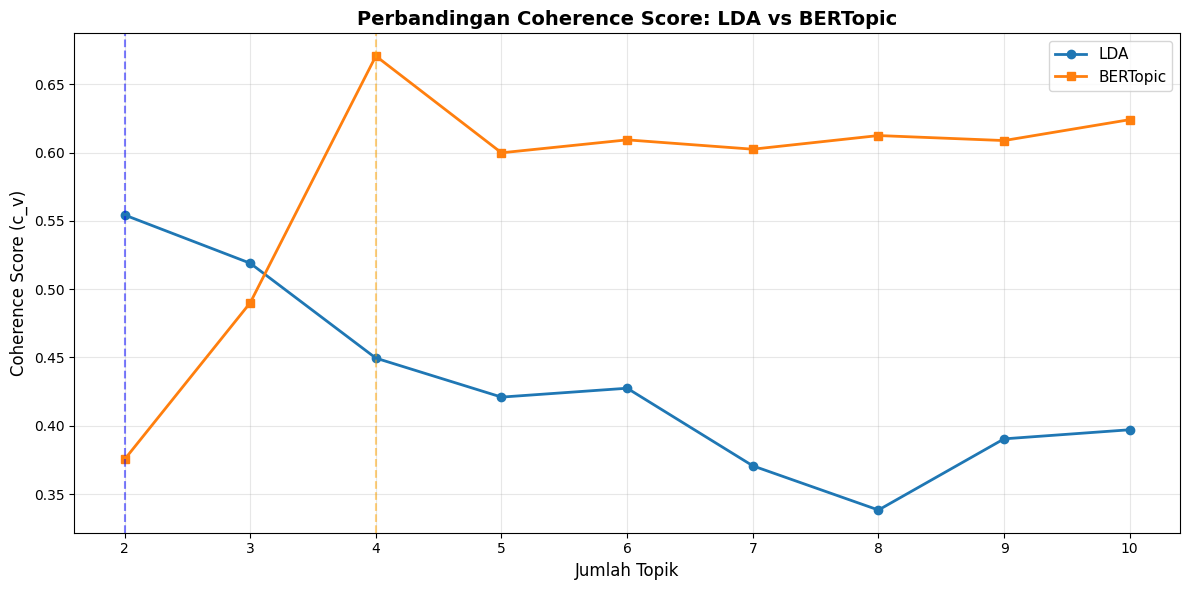

In [ ]:
print("\n" + "="*60)
print("VISUALISASI PERBANDINGAN HASIL PEMODELAN TOPIK")
print("="*60 + "\n")

import matplotlib.pyplot as plt

# Plot perbandingan coherence score
plt.figure(figsize=(12, 6))
plt.plot(num_topics_list, coherence_scores, marker='o', label='LDA', linewidth=2)
plt.plot(bertopic_num_topics_list, bertopic_coherence_scores, marker='s', label='BERTopic', linewidth=2)
plt.xlabel('Jumlah Topik', fontsize=12)
plt.ylabel('Coherence Score (c_v)', fontsize=12)
plt.title('Perbandingan Coherence Score: LDA vs BERTopic', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(num_topics_list)

# Tandai nilai terbaik
plt.axvline(x=best_num_topics, color='blue', linestyle='--', alpha=0.5, label=f'LDA Terbaik ({best_num_topics} topik)')
plt.axvline(x=best_bertopic_num_topics, color='orange', linestyle='--', alpha=0.5, label=f'BERTopic Terbaik ({best_bertopic_num_topics} topik)')

plt.tight_layout()
plt.show()


EVALUASI LENGKAP: COHERENCE + DIVERSITY

EVALUASI LDA

Menghitung metrik untuk setiap model LDA...

Jumlah Topik: 2
  Coherence Score (c_v): 0.5543
  Topic Diversity      : 1.0000

Jumlah Topik: 3
  Coherence Score (c_v): 0.5190
  Topic Diversity      : 1.0000

Jumlah Topik: 4
  Coherence Score (c_v): 0.4495
  Topic Diversity      : 1.0000

Jumlah Topik: 5
  Coherence Score (c_v): 0.4210
  Topic Diversity      : 1.0000

Jumlah Topik: 6
  Coherence Score (c_v): 0.4275
  Topic Diversity      : 1.0000

Jumlah Topik: 7
  Coherence Score (c_v): 0.3707
  Topic Diversity      : 1.0000

Jumlah Topik: 8
  Coherence Score (c_v): 0.3383
  Topic Diversity      : 1.0000

Jumlah Topik: 9
  Coherence Score (c_v): 0.3904
  Topic Diversity      : 1.0000

Jumlah Topik: 10
  Coherence Score (c_v): 0.3971
  Topic Diversity      : 1.0000

------------------------------------------------------------
MODEL LDA TERBAIK (berdasarkan Coherence)
  Jumlah Topik         : 2
  Coherence Score (c_v): 0.5543
  Topic

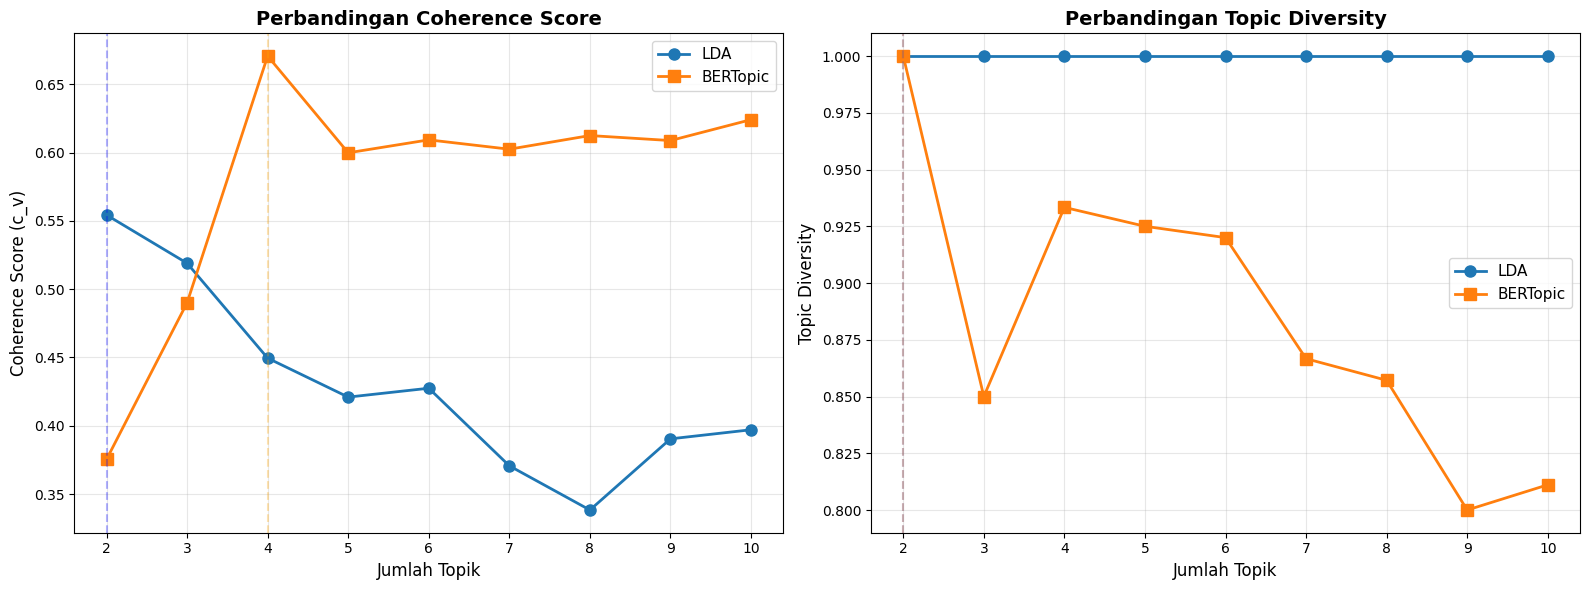


KESIMPULAN EVALUASI

📊 METRIK EVALUASI:
------------------------------------------------------------

🏆 MODEL TERBAIK:
------------------------------------------------------------

Berdasarkan Coherence Score:
  Winner: BERTopic (4 topik)
  Coherence: 0.6707 vs 0.5543

Berdasarkan Topic Diversity:
  Winner: BERTopic
  Diversity: 1.0000 vs 1.0000


In [ ]:
# ============================================================================
# EVALUASI TOPIC MODELING: COHERENCE SCORE + TOPIC DIVERSITY
# ============================================================================

print("\n" + "="*60)
print("EVALUASI LENGKAP: COHERENCE + DIVERSITY")
print("="*60 + "\n")

from gensim.models.coherencemodel import CoherenceModel

# ----------------------------------------------------------------------------
# FUNGSI HELPER
# ----------------------------------------------------------------------------

def calculate_topic_diversity(topics, top_n=10):
    """Menghitung Topic Diversity Score"""
    top_words = []
    for topic in topics:
        top_words.extend(topic[:top_n])

    unique_words = len(set(top_words))
    total_words = len(top_words)

    diversity_score = unique_words / total_words if total_words > 0 else 0
    return diversity_score


def get_topics_from_lda(lda_model, top_n=10):
    """Ekstrak topik dari LDA"""
    topics = []
    for topic_id in range(lda_model.num_topics):
        topic_words = lda_model.show_topic(topic_id, topn=top_n)
        words = [word for word, _ in topic_words]
        topics.append(words)
    return topics


def get_topics_from_bertopic(topic_model, topic_info, top_n=10):
    """Ekstrak topik dari BERTopic"""
    topics = []
    valid_topics = topic_info[topic_info['Topic'] != -1]['Topic'].tolist()

    for topic_id in valid_topics:
        topic_words = topic_model.get_topic(topic_id)
        words = [word for word, _ in topic_words[:top_n]]
        topics.append(words)

    return topics


# ----------------------------------------------------------------------------
# EVALUASI LDA
# ----------------------------------------------------------------------------

print("="*60)
print("EVALUASI LDA")
print("="*60 + "\n")

lda_coherence_scores = []
lda_diversity_scores = []

print("Menghitung metrik untuk setiap model LDA...\n")

for i, lda_model in enumerate(lda_models):
    num_topics = num_topics_list[i]

    # 1. Coherence Score c_v
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_cv = coherence_model.get_coherence()
    lda_coherence_scores.append(coherence_cv)

    # 2. Topic Diversity
    topics = get_topics_from_lda(lda_model, top_n=10)
    diversity = calculate_topic_diversity(topics, top_n=10)
    lda_diversity_scores.append(diversity)

    print(f"Jumlah Topik: {num_topics}")
    print(f"  Coherence Score (c_v): {coherence_cv:.4f}")
    print(f"  Topic Diversity      : {diversity:.4f}")
    print()

# Tentukan model LDA terbaik
best_lda_idx = lda_coherence_scores.index(max(lda_coherence_scores))
best_lda_num_topics = num_topics_list[best_lda_idx]
best_lda_coherence = lda_coherence_scores[best_lda_idx]
best_lda_diversity = lda_diversity_scores[best_lda_idx]

print("-" * 60)
print(f"MODEL LDA TERBAIK (berdasarkan Coherence)")
print(f"  Jumlah Topik         : {best_lda_num_topics}")
print(f"  Coherence Score (c_v): {best_lda_coherence:.4f}")
print(f"  Topic Diversity      : {best_lda_diversity:.4f}")
print()

# ----------------------------------------------------------------------------
# EVALUASI BERTOPIC
# ----------------------------------------------------------------------------

print("="*60)
print("EVALUASI BERTOPIC")
print("="*60 + "\n")

bertopic_coherence_scores = []
bertopic_diversity_scores = []

print("Menghitung metrik untuk setiap model BERTopic...\n")

for i, topic_model in enumerate(bertopic_models):
    num_topics = bertopic_num_topics_list[i]
    topic_info = bertopic_topics_info[i]

    # 1. Coherence Score c_v
    bertopic_topics = get_topics_from_bertopic(topic_model, topic_info, top_n=10)

    coherence_model = CoherenceModel(
        topics=bertopic_topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_cv = coherence_model.get_coherence()
    bertopic_coherence_scores.append(coherence_cv)

    # 2. Topic Diversity
    diversity = calculate_topic_diversity(bertopic_topics, top_n=10)
    bertopic_diversity_scores.append(diversity)

    print(f"Jumlah Topik: {num_topics}")
    print(f"  Coherence Score (c_v): {coherence_cv:.4f}")
    print(f"  Topic Diversity      : {diversity:.4f}")
    print()

# Tentukan model BERTopic terbaik
best_bertopic_idx = bertopic_coherence_scores.index(max(bertopic_coherence_scores))
best_bertopic_num_topics = bertopic_num_topics_list[best_bertopic_idx]
best_bertopic_coherence = bertopic_coherence_scores[best_bertopic_idx]
best_bertopic_diversity = bertopic_diversity_scores[best_bertopic_idx]

print("-" * 60)
print(f"MODEL BERTOPIC TERBAIK (berdasarkan Coherence)")
print(f"  Jumlah Topik         : {best_bertopic_num_topics}")
print(f"  Coherence Score (c_v): {best_bertopic_coherence:.4f}")
print(f"  Topic Diversity      : {best_bertopic_diversity:.4f}")
print()

# ----------------------------------------------------------------------------
# PERBANDINGAN LENGKAP
# ----------------------------------------------------------------------------

print("="*60)
print("PERBANDINGAN LENGKAP LDA vs BERTOPIC")
print("="*60 + "\n")

import pandas as pd

comparison_df = pd.DataFrame({
    'Jumlah_Topik': num_topics_list,
    'LDA_Coherence': lda_coherence_scores,
    'LDA_Diversity': lda_diversity_scores,
    'BERTopic_Coherence': bertopic_coherence_scores,
    'BERTopic_Diversity': bertopic_diversity_scores,
    'Coherence_Diff': [b - l for l, b in zip(lda_coherence_scores, bertopic_coherence_scores)],
    'Diversity_Diff': [b - l for l, b in zip(lda_diversity_scores, bertopic_diversity_scores)]
})

print(comparison_df.to_string(index=False))

# ----------------------------------------------------------------------------
# VISUALISASI
# ----------------------------------------------------------------------------

print("\n" + "="*60)
print("VISUALISASI PERBANDINGAN")
print("="*60 + "\n")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Coherence Score
axes[0].plot(num_topics_list, lda_coherence_scores, marker='o', label='LDA', linewidth=2, markersize=8)
axes[0].plot(bertopic_num_topics_list, bertopic_coherence_scores, marker='s', label='BERTopic', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Topik', fontsize=12)
axes[0].set_ylabel('Coherence Score (c_v)', fontsize=12)
axes[0].set_title('Perbandingan Coherence Score', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(num_topics_list)

# Tandai nilai terbaik
axes[0].axvline(x=best_lda_num_topics, color='blue', linestyle='--', alpha=0.3)
axes[0].axvline(x=best_bertopic_num_topics, color='orange', linestyle='--', alpha=0.3)

# Plot 2: Topic Diversity
axes[1].plot(num_topics_list, lda_diversity_scores, marker='o', label='LDA', linewidth=2, markersize=8)
axes[1].plot(bertopic_num_topics_list, bertopic_diversity_scores, marker='s', label='BERTopic', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Topik', fontsize=12)
axes[1].set_ylabel('Topic Diversity', fontsize=12)
axes[1].set_title('Perbandingan Topic Diversity', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(num_topics_list)

# Tandai nilai terbaik
best_lda_div_idx = lda_diversity_scores.index(max(lda_diversity_scores))
best_bertopic_div_idx = bertopic_diversity_scores.index(max(bertopic_diversity_scores))

axes[1].axvline(x=num_topics_list[best_lda_div_idx], color='blue', linestyle='--', alpha=0.3)
axes[1].axvline(x=bertopic_num_topics_list[best_bertopic_div_idx], color='orange', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# KESIMPULAN
# ----------------------------------------------------------------------------

print("\n" + "="*60)
print("KESIMPULAN EVALUASI")
print("="*60 + "\n")

print("📊 METRIK EVALUASI:")
print("-" * 60)

print("\n🏆 MODEL TERBAIK:")
print("-" * 60)

print(f"\nBerdasarkan Coherence Score:")
if best_lda_coherence > best_bertopic_coherence:
    print(f"  Winner: LDA ({best_lda_num_topics} topik)")
    print(f"  Coherence: {best_lda_coherence:.4f} vs {best_bertopic_coherence:.4f}")
else:
    print(f"  Winner: BERTopic ({best_bertopic_num_topics} topik)")
    print(f"  Coherence: {best_bertopic_coherence:.4f} vs {best_lda_coherence:.4f}")

print(f"\nBerdasarkan Topic Diversity:")
best_lda_div = max(lda_diversity_scores)
best_bertopic_div = max(bertopic_diversity_scores)

if best_lda_div > best_bertopic_div:
    print(f"  Winner: LDA")
    print(f"  Diversity: {best_lda_div:.4f} vs {best_bertopic_div:.4f}")
else:
    print(f"  Winner: BERTopic")
    print(f"  Diversity: {best_bertopic_div:.4f} vs {best_lda_div:.4f}")

# Perbandingan Assignment

In [ ]:
# ============================================================================
# PERBANDINGAN ASSIGNMENT: LDA vs BERTOPIC
# ============================================================================

print("="*60)
print("PERBANDINGAN ASSIGNMENT: LDA vs BERTOPIC")
print("="*60 + "\n")

# Gabungkan kedua assignment
df_comparison = df.copy()
df_comparison['LDA_Topic'] = df_with_lda_topics['LDA_Topic']
df_comparison['LDA_Prob'] = df_with_lda_topics['LDA_Topic_Prob']
df_comparison['BERTopic_Topic'] = df_with_bertopic_topics['BERTopic_Topic']
df_comparison['BERTopic_Prob'] = df_with_bertopic_topics['BERTopic_Topic_Prob']

# Tampilkan 20 dokumen pertama
print("Perbandingan assignment untuk 20 dokumen pertama:\n")
print(df_comparison[['final_text', 'LDA_Topic', 'LDA_Prob', 'BERTopic_Topic', 'BERTopic_Prob']].head(20).to_string())

# Hitung agreement
df_comparison_numeric = df_comparison[df_comparison['BERTopic_Topic'] != 'Outlier'].copy()
df_comparison_numeric['BERTopic_Topic'] = pd.to_numeric(df_comparison_numeric['BERTopic_Topic'])

agreement = (df_comparison_numeric['LDA_Topic'] == df_comparison_numeric['BERTopic_Topic']).sum()
total = len(df_comparison_numeric)
agreement_rate = agreement / total * 100

print(f"\n{'='*60}")
print(f"TINGKAT AGREEMENT LDA vs BERTOPIC")
print(f"{'='*60}")
print(f"\nDokumen yang sama topiknya: {agreement}/{total} ({agreement_rate:.2f}%)")
print(f"Dokumen yang beda topiknya: {total-agreement}/{total} ({100-agreement_rate:.2f}%)")

PERBANDINGAN ASSIGNMENT: LDA vs BERTOPIC

Perbandingan assignment untuk 20 dokumen pertama:

                                                                                                     final_text  LDA_Topic  LDA_Prob BERTopic_Topic  BERTopic_Prob
0                                                                                 aplikasi manfaat urus listrik          1  0.801217              1       1.000000
1                                                                                              bantu proses adu          1  0.770726              2       0.268198
2                                                                                           mudah cepat tanggap          2  0.535573              2       0.648058
3                                                                           hadir aplikasi ganggu listrik rumah          1  0.716561              1       1.000000
4                                                   lapor langsung pln pakai pln mobile muda

In [ ]:
# ============================================================================
# EXPORT HASIL ASSIGNMENT KE CSV
# ============================================================================

print("\n" + "="*60)
print("EXPORT HASIL KE CSV")
print("="*60 + "\n")

# Export LDA
df_with_lda_topics.to_csv('lda_topic_assignments.csv', index=False, encoding='utf-8')
print("✓ File 'lda_topic_assignments.csv' berhasil disimpan")

# Export BERTopic
df_with_bertopic_topics.to_csv('bertopic_topic_assignments.csv', index=False, encoding='utf-8')
print("✓ File 'bertopic_topic_assignments.csv' berhasil disimpan")

# Export Comparison
df_comparison.to_csv('topic_assignments_comparison.csv', index=False, encoding='utf-8')
print("✓ File 'topic_assignments_comparison.csv' berhasil disimpan")

print("\n" + "="*60)
print("SELESAI!")
print("="*60)

# Word Cloud Topik LDA dan BERTopic


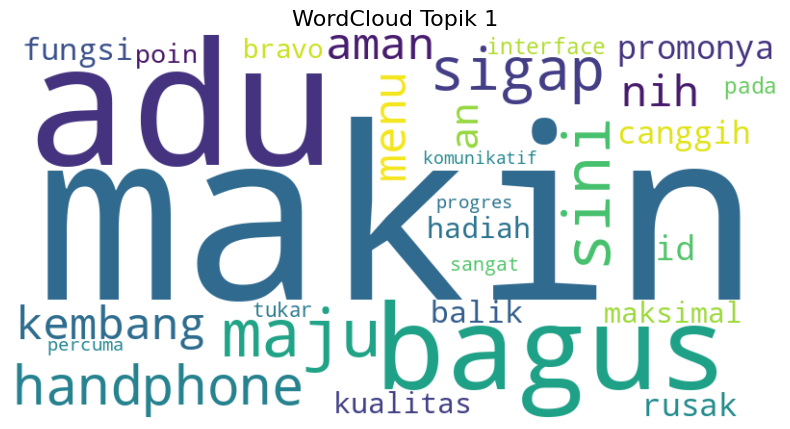

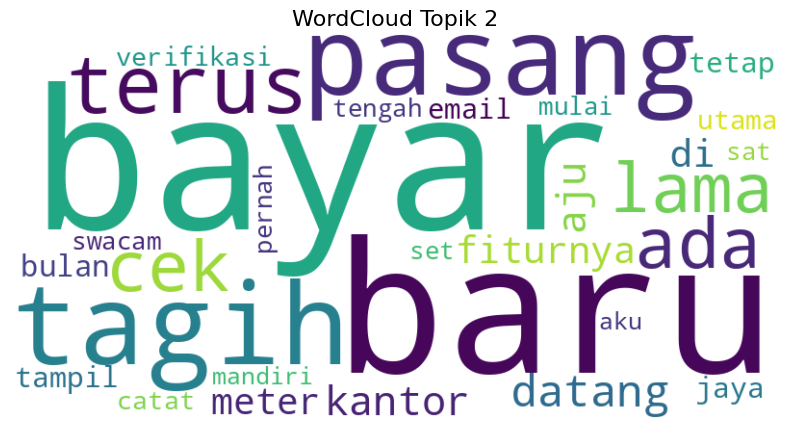

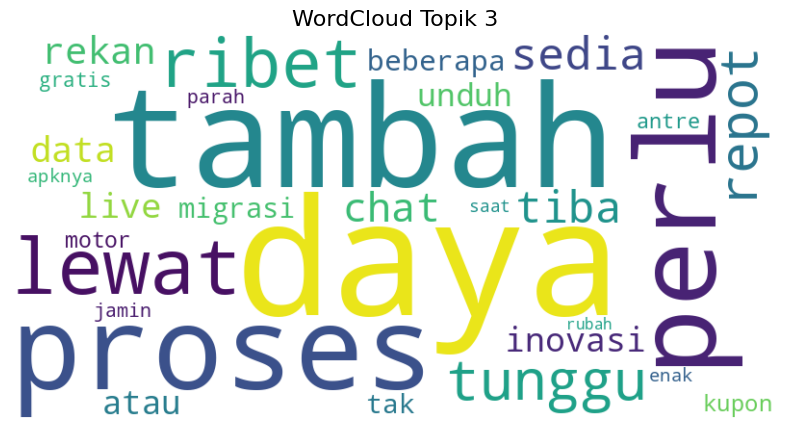

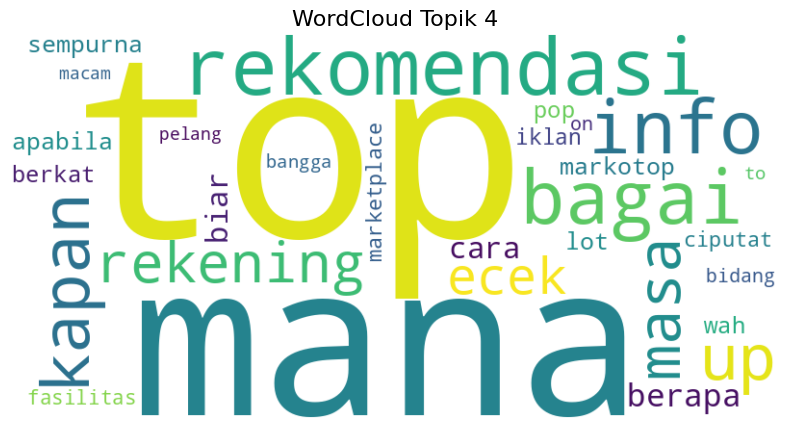

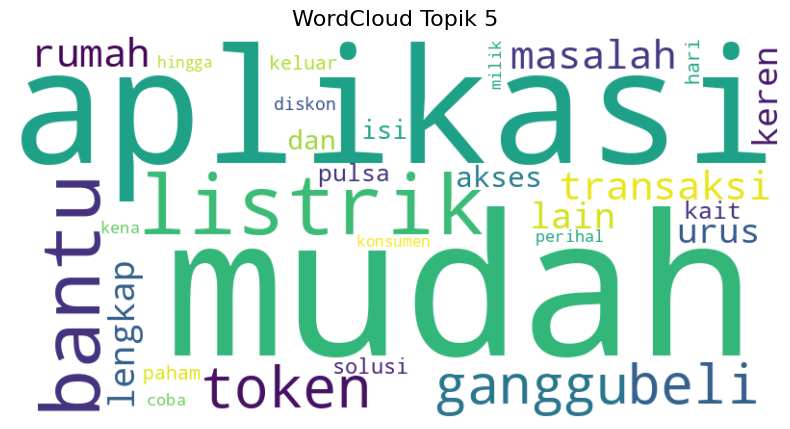

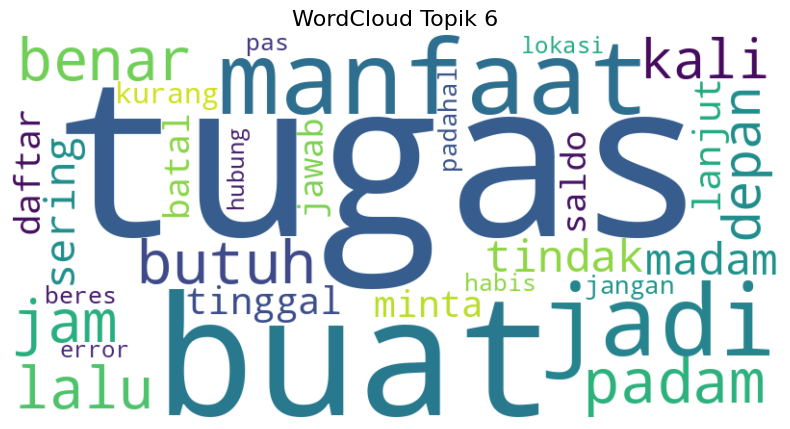

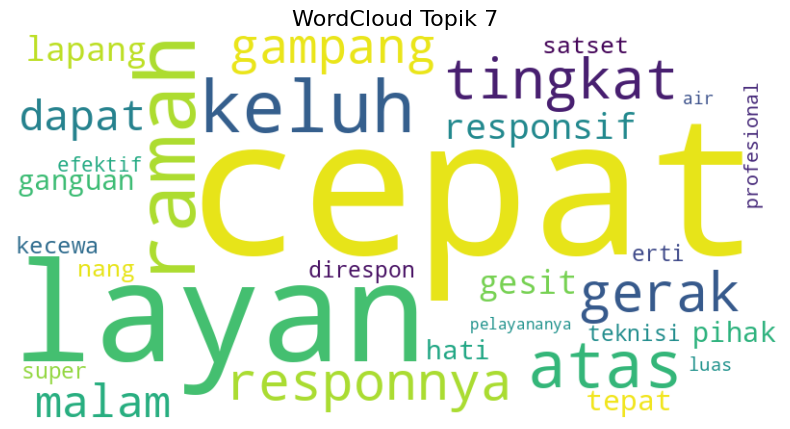

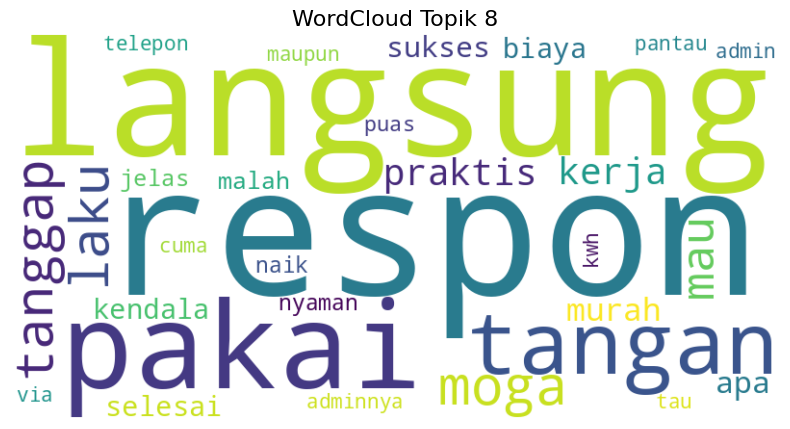

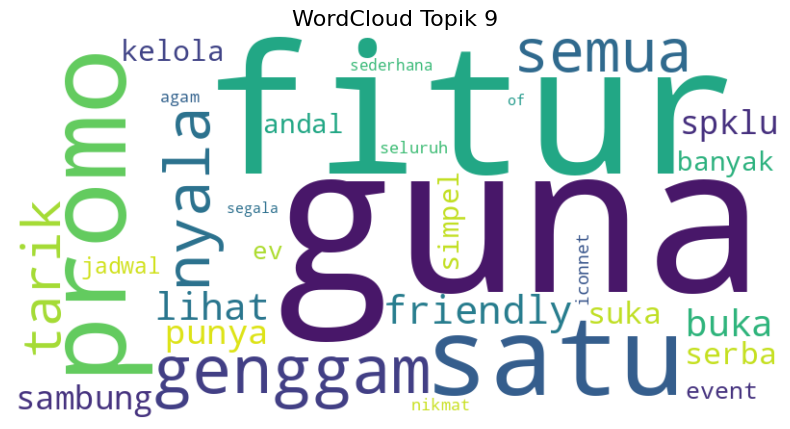

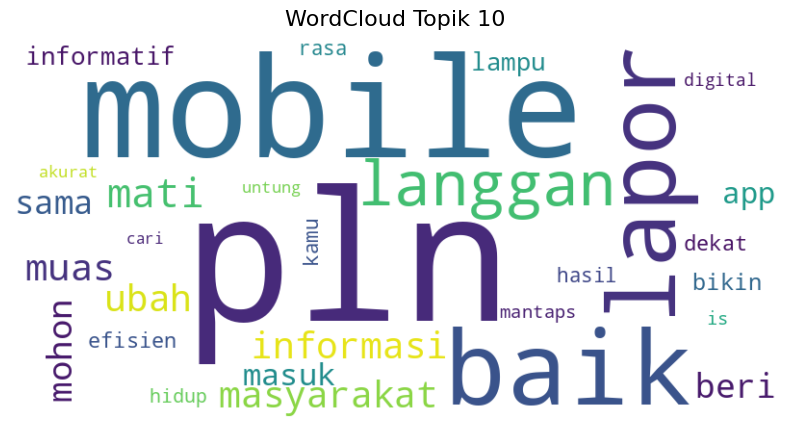

In [ ]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

lda_model.show_topic(topic_id, topn=20)

# Word Cloud Setiap Topik LDA
num_topics = lda_model.num_topics

for topic_id in range(num_topics):
    # Ambil kata & bobot topik
    topic_words = dict(lda_model.show_topic(topic_id, topn=30))

    # Generate wordcloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(topic_words)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud Topik {topic_id+1}", fontsize=16)
    plt.show()


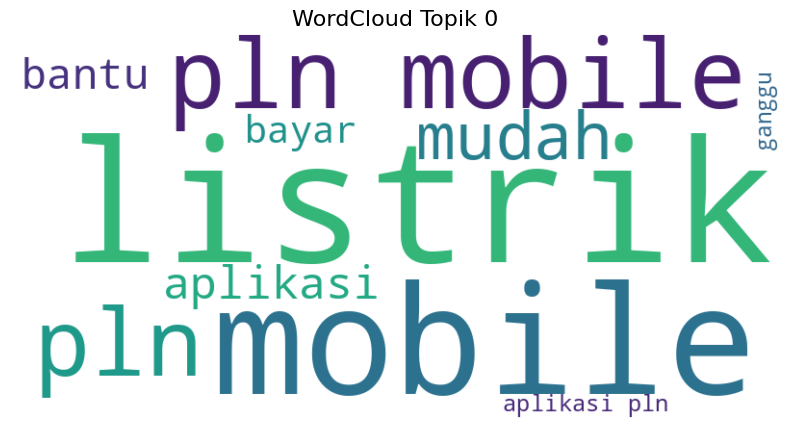

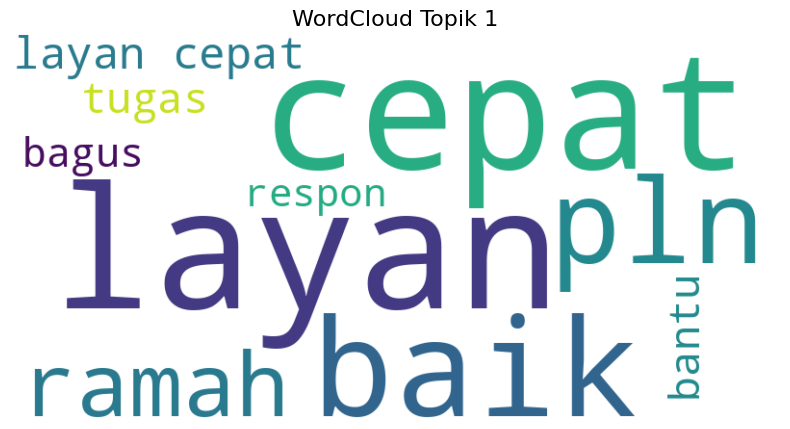

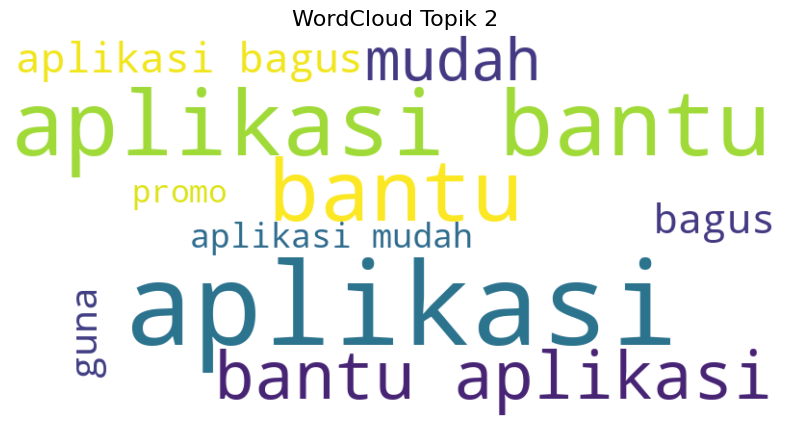

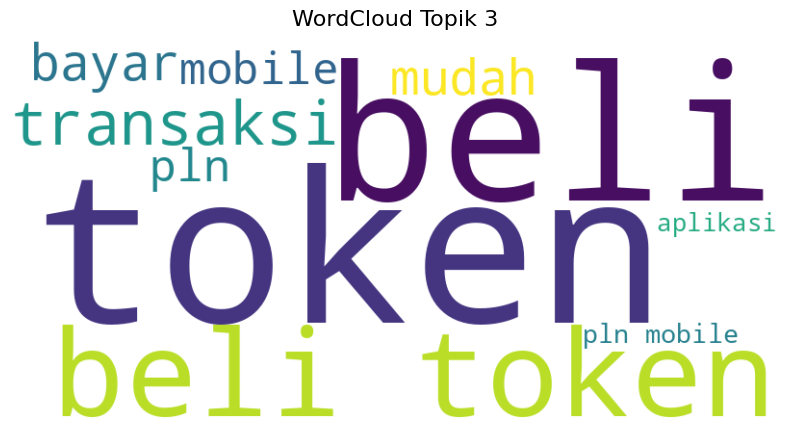

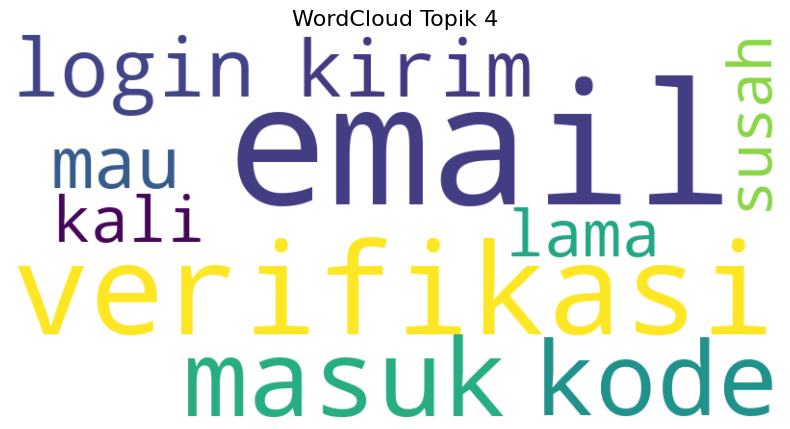

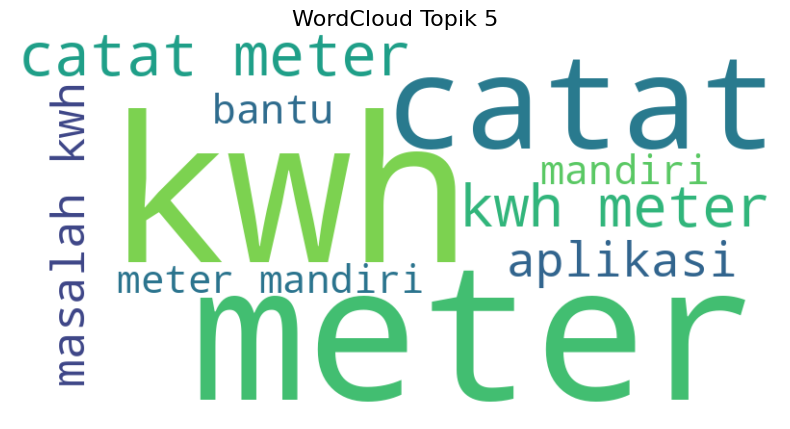

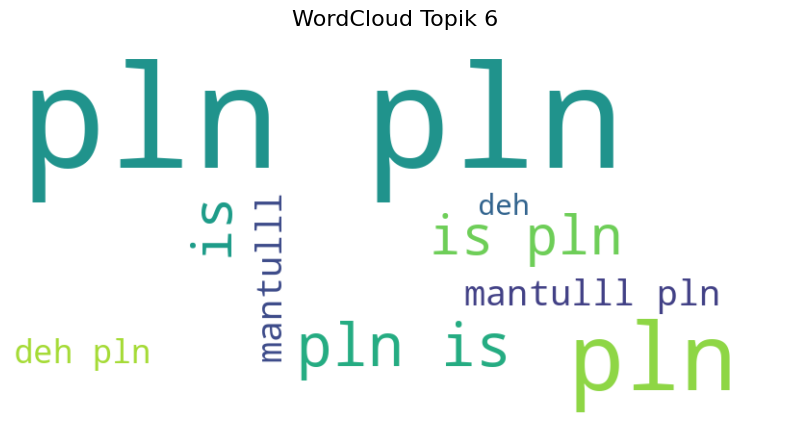

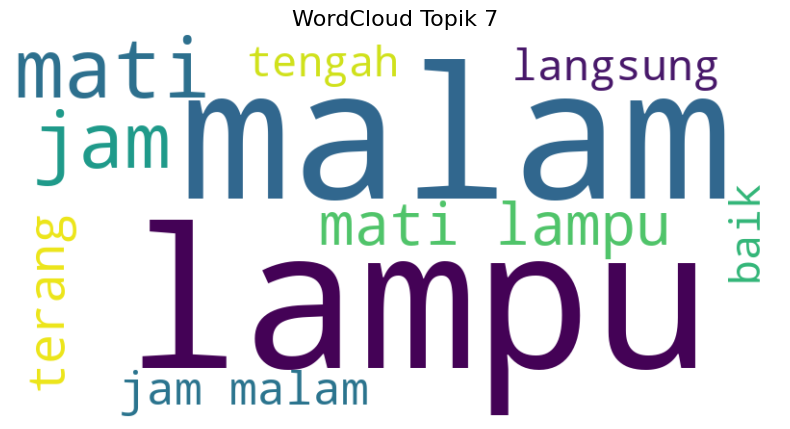

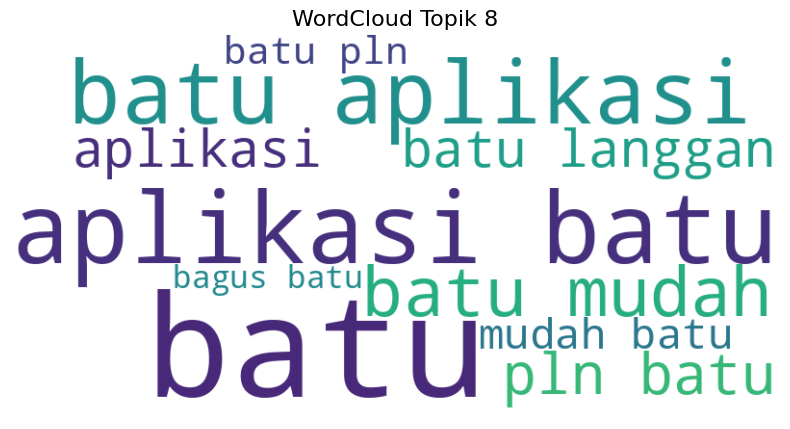

In [ ]:
topic_model.get_topic(topic_id)

# Word Cloud BERTopic
topics = topic_model.get_topic_info()
topics = topics[topics.Topic != -1]  # buang outlier

for topic_id in topics.Topic:
    # Ambil kata & bobot topik
    topic_words = dict(topic_model.get_topic(topic_id))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(topic_words)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud Topik {topic_id}", fontsize=16)
    plt.show()


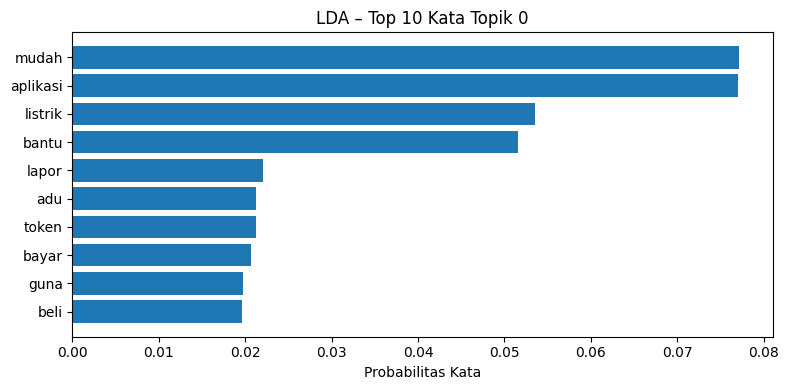

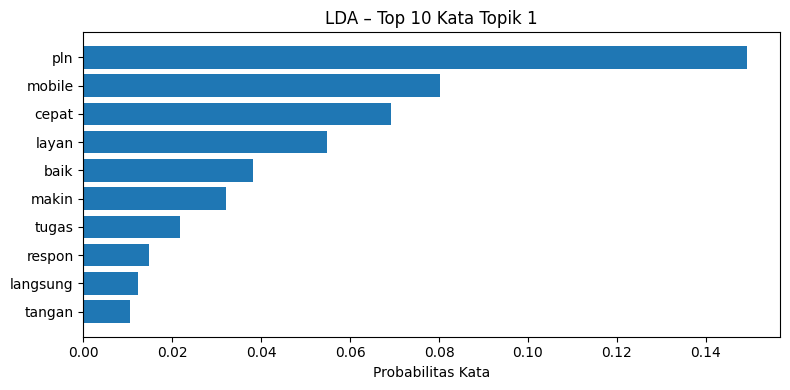

In [ ]:
import matplotlib.pyplot as plt

num_words = 10

for topic_id in range(best_num_topics):
    words_probs = best_lda_model.show_topic(topic_id, num_words)

    words = [w for w, _ in words_probs]
    probs = [p for _, p in words_probs]

    plt.figure(figsize=(8,4))
    plt.barh(words, probs)
    plt.gca().invert_yaxis()
    plt.title(f"LDA – Top 10 Kata Topik {topic_id}")
    plt.xlabel("Probabilitas Kata")
    plt.tight_layout()
    plt.show()


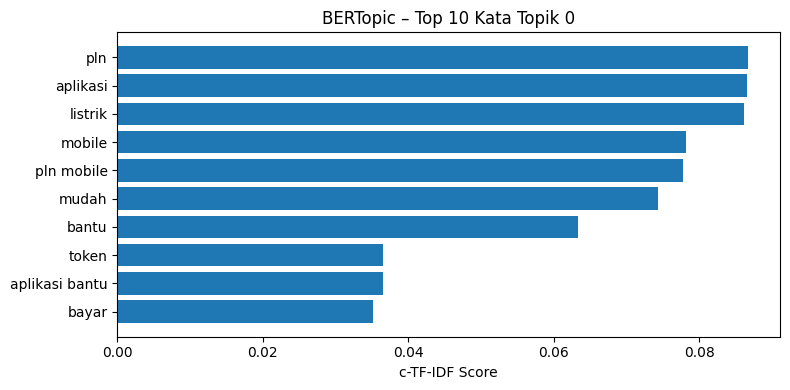

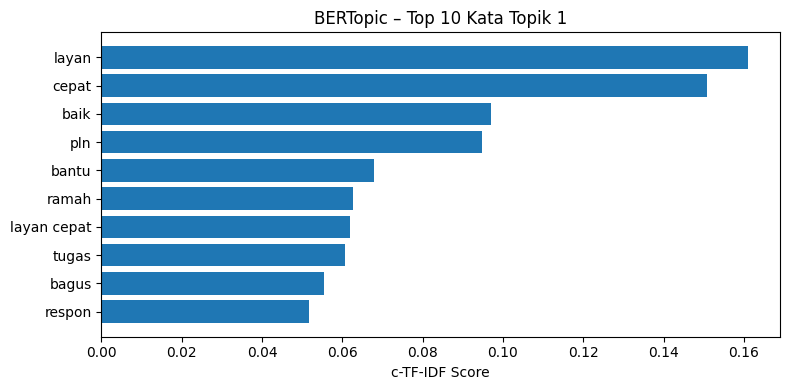

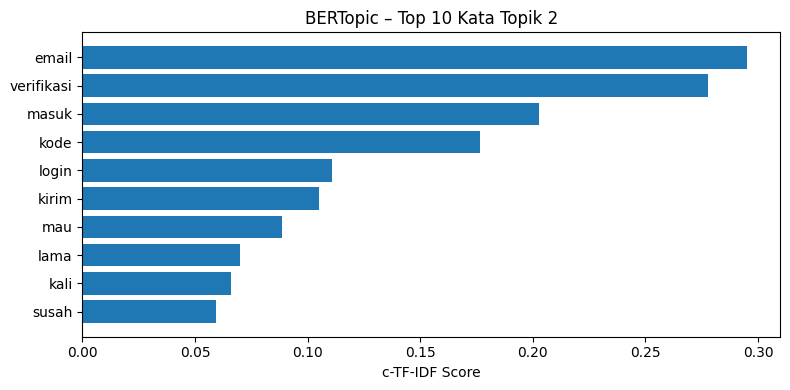

In [ ]:
topic_info = best_bertopic_model.get_topic_info()
valid_topics = topic_info[topic_info.Topic != -1].Topic.tolist()

for topic_id in valid_topics:
    words_scores = best_bertopic_model.get_topic(topic_id)[:10]

    words = [w for w, _ in words_scores]
    scores = [s for _, s in words_scores]

    plt.figure(figsize=(8,4))
    plt.barh(words, scores)
    plt.gca().invert_yaxis()
    plt.title(f"BERTopic – Top 10 Kata Topik {topic_id}")
    plt.xlabel("c-TF-IDF Score")
    plt.tight_layout()
    plt.show()
